# Perbandingan Naïve Bayes dan Random Forest untuk Analisis Sentimen Ulasan Aplikasi Gojek Berbahasa Indonesia Menggunakan TF-IDF

**Peneliti:** Mohamad Gilang Rizki Riomdona (240202903)  
**Program Studi:** Ilmu Komputer — Universitas Putra Bangsa Kebumen  
**Dosen Pengampu:** Helmi Bahar Alim, S.Kom., M.Kom  
**Random Seed:** 42  
**Dataset:** gojek_labeled.csv (Kaggle)  

## 0. Install & Import Library

In [17]:
# Install library yang dibutuhkan
!pip install PySastrawi -q
!pip install nltk -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import nltk
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# Download stopwords NLTK
nltk.download('stopwords', quiet=True)

# ============================================================
# RANDOM SEED — dikunci tetap untuk reproducibility
# ============================================================
SEED = 42
np.random.seed(SEED)

print('✅ Semua library berhasil diimport')
print(f'   Seed: {SEED}')

✅ Semua library berhasil diimport
   Seed: 42


## 1. Load & Sampling Dataset

In [19]:
# ============================================================
# Load dataset
# Jika di Colab, upload file dulu atau mount Google Drive
# ============================================================

# Jika pakai Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_PATH = '/content/drive/MyDrive/gojek_labeled.csv'

# Jika upload langsung ke Colab:
FILE_PATH = r'C:\Users\VICTUS\RTI\Dataset\gojek_labeled.csv'

df_full = pd.read_csv(FILE_PATH, low_memory=False)
print(f'Total baris dataset asli : {len(df_full):,}')
print(f'Distribusi sentiment asli :')
print(df_full['sentiment'].value_counts())

Total baris dataset asli : 1,594,491
Distribusi sentiment asli :
sentiment
positif    1282923
negatif     311568
Name: count, dtype: int64


In [20]:
# ============================================================
# Sampling Stratified: 50.000 positif + 50.000 negatif
# Alasan: dataset imbalanced (80:20), sampling balanced
# memastikan fairness comparison antar algoritma
# ============================================================

SAMPLE_PER_CLASS = 50_000

# Hapus baris dengan content kosong terlebih dahulu
df_full = df_full.dropna(subset=['content', 'sentiment'])
df_full = df_full[df_full['content'].str.strip() != '']

df_positif = df_full[df_full['sentiment'] == 'positif'].sample(
    n=SAMPLE_PER_CLASS, random_state=SEED
)
df_negatif = df_full[df_full['sentiment'] == 'negatif'].sample(
    n=SAMPLE_PER_CLASS, random_state=SEED
)

df = pd.concat([df_positif, df_negatif]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Total data setelah sampling : {len(df):,}')
print(f'Distribusi sentiment        :')
print(df['sentiment'].value_counts())
print()
print('Contoh data:')
df[['content', 'sentiment']].head(5)

Total data setelah sampling : 100,000
Distribusi sentiment        :
sentiment
negatif    50000
positif    50000
Name: count, dtype: int64

Contoh data:


,content,sentiment
0,Setelah aplikasi gojek bergabung di goto aplik...,negatif
1,Tai,negatif
2,"9,5/10",positif
3,Terlalu lama respon aplikasinya,negatif
4,Makin buruk,negatif


## 2. Preprocessing Teks

In [21]:
# ============================================================
# Inisialisasi tools preprocessing
# ============================================================

# Stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Stopwords Bahasa Indonesia dari NLTK
stop_words_id = set(stopwords.words('indonesian'))

print(f'✅ Stemmer Sastrawi siap')
print(f'✅ Stopwords Indonesia: {len(stop_words_id)} kata')

✅ Stemmer Sastrawi siap
✅ Stopwords Indonesia: 757 kata


In [22]:
def preprocess(text):
    """
    Pipeline preprocessing:
    1. Case folding  — ubah ke huruf kecil
    2. Cleansing     — hapus URL, angka, simbol, karakter non-alfabet
    3. Stopword removal — hapus stopword Bahasa Indonesia
    4. Stemming      — reduksi kata ke bentuk dasar (Sastrawi)
    """
    if not isinstance(text, str):
        return ''

    # 1. Case folding
    text = text.lower()

    # 2. Cleansing
    text = re.sub(r'http\S+|www\.\S+', '', text)   # hapus URL
    text = re.sub(r'[^a-z\s]', ' ', text)           # hapus angka & simbol
    text = re.sub(r'\s+', ' ', text).strip()         # normalisasi spasi

    # 3. Stopword removal
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words_id]

    # 4. Stemming
    tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)


# Uji preprocessing
contoh = "udh gw uninstall aplikasi gojek! ga ada perbaikan sistem, hanya mempersulit customer."
print('Sebelum:', contoh)
print('Sesudah:', preprocess(contoh))

Sebelum: udh gw uninstall aplikasi gojek! ga ada perbaikan sistem, hanya mempersulit customer.
Sesudah: udh gw uninstall aplikasi gojek ga baik sistem sulit customer


In [23]:
# ============================================================
# Terapkan preprocessing ke seluruh dataset
# (proses ini memakan waktu beberapa menit karena stemming)
# ============================================================

print('Memulai preprocessing... (estimasi 5-15 menit)')
start = time.time()

df['content_clean'] = df['content'].apply(preprocess)

elapsed = time.time() - start
print(f'✅ Preprocessing selesai dalam {elapsed/60:.1f} menit')

# Hapus baris yang setelah preprocessing jadi kosong
df = df[df['content_clean'].str.strip() != ''].reset_index(drop=True)
print(f'Total data setelah preprocessing: {len(df):,}')

# Tampilkan sampel
df[['content', 'content_clean', 'sentiment']].head(5)

Memulai preprocessing... (estimasi 5-15 menit)
✅ Preprocessing selesai dalam 0.2 menit
Total data setelah preprocessing: 97,223


,content,content_clean,sentiment
0,Setelah aplikasi gojek bergabung di goto aplik...,aplikasi gojek gabung goto aplikasi kekurangan...,negatif
1,Tai,tai,negatif
2,Terlalu lama respon aplikasinya,respon aplikasi,negatif
3,Makin buruk,buruk,negatif
4,Begini banget yaa aplikasi karya anak bangsa. ...,banget yaa aplikasi karya anak bangsa suka nge...,negatif


## 3. Ekstraksi Fitur — TF-IDF

In [24]:
# ============================================================
# Split data: 80% train, 20% test
# random_state=42 untuk reproducibility
# ============================================================

X = df['content_clean']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y   # pastikan distribusi kelas seimbang di train & test
)

print(f'Data latih : {len(X_train):,} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Data uji   : {len(X_test):,} ({len(X_test)/len(df)*100:.0f}%)')
print()
print('Distribusi kelas data latih:')
print(y_train.value_counts())
print()
print('Distribusi kelas data uji:')
print(y_test.value_counts())

Data latih : 77,778 (80%)
Data uji   : 19,445 (20%)

Distribusi kelas data latih:
sentiment
negatif    39677
positif    38101
Name: count, dtype: int64

Distribusi kelas data uji:
sentiment
negatif    9919
positif    9526
Name: count, dtype: int64


In [25]:
# ============================================================
# TF-IDF Vectorizer
# Parameter sesuai proposal:
# - max_features = 5000
# - ngram_range  = (1,1) — unigram
# PENTING: fit HANYA pada data latih, transform keduanya
# (mencegah data leakage)
# ============================================================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1)
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform data latih
X_test_tfidf  = tfidf.transform(X_test)         # transform saja data uji

print(f'✅ TF-IDF selesai')
print(f'   Shape X_train : {X_train_tfidf.shape}')
print(f'   Shape X_test  : {X_test_tfidf.shape}')
print(f'   Jumlah fitur  : {len(tfidf.vocabulary_):,}')

✅ TF-IDF selesai
   Shape X_train : (77778, 5000)
   Shape X_test  : (19445, 5000)
   Jumlah fitur  : 5,000


## 4. Pelatihan & Evaluasi Model

In [26]:
# ============================================================
# Fungsi evaluasi — digunakan untuk kedua kondisi
# ============================================================

def evaluate_model(model, X_test, y_test, nama_model):
    """Hitung dan tampilkan metrik evaluasi."""
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='positif', average='binary')
    rec  = recall_score(y_test, y_pred, pos_label='positif', average='binary')
    f1   = f1_score(y_test, y_pred, pos_label='positif', average='binary')

    print(f'\n{'='*50}')
    print(f'  {nama_model}')
    print(f'{'='*50}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec*100:.2f}%')
    print(f'  Recall    : {rec*100:.2f}%')
    print(f'  F1-Score  : {f1*100:.2f}%')
    print()
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

    return {
        'model': nama_model,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'y_pred': y_pred
    }

In [27]:
# ============================================================
# KONDISI A: Multinomial Naïve Bayes
# Parameter: alpha=1.0 (Laplace smoothing, default)
# ============================================================

print('Melatih Naïve Bayes...')
start = time.time()

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

waktu_nb = time.time() - start
print(f'✅ Naïve Bayes selesai dilatih dalam {waktu_nb:.2f} detik')

hasil_nb = evaluate_model(nb_model, X_test_tfidf, y_test, 'Naïve Bayes (Kondisi A)')

Melatih Naïve Bayes...
✅ Naïve Bayes selesai dilatih dalam 0.13 detik

  Naïve Bayes (Kondisi A)
  Accuracy  : 89.53%
  Precision : 93.83%
  Recall    : 84.17%
  F1-Score  : 88.74%

Classification Report:
              precision    recall  f1-score   support

     negatif       0.86      0.95      0.90      9919
     positif       0.94      0.84      0.89      9526

    accuracy                           0.90     19445
   macro avg       0.90      0.89      0.89     19445
weighted avg       0.90      0.90      0.89     19445



In [28]:
# ============================================================
# KONDISI B: Random Forest
# Parameter: n_estimators=100 (default)
# ============================================================

print('Melatih Random Forest... (estimasi 1-3 menit)')
start = time.time()

rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_model.fit(X_train_tfidf, y_train)

waktu_rf = time.time() - start
print(f'✅ Random Forest selesai dilatih dalam {waktu_rf:.2f} detik')

hasil_rf = evaluate_model(rf_model, X_test_tfidf, y_test, 'Random Forest (Kondisi B)')

Melatih Random Forest... (estimasi 1-3 menit)
✅ Random Forest selesai dilatih dalam 152.46 detik

  Random Forest (Kondisi B)
  Accuracy  : 89.92%
  Precision : 91.20%
  Recall    : 87.90%
  F1-Score  : 89.52%

Classification Report:
              precision    recall  f1-score   support

     negatif       0.89      0.92      0.90      9919
     positif       0.91      0.88      0.90      9526

    accuracy                           0.90     19445
   macro avg       0.90      0.90      0.90     19445
weighted avg       0.90      0.90      0.90     19445



## 5. Visualisasi Confusion Matrix

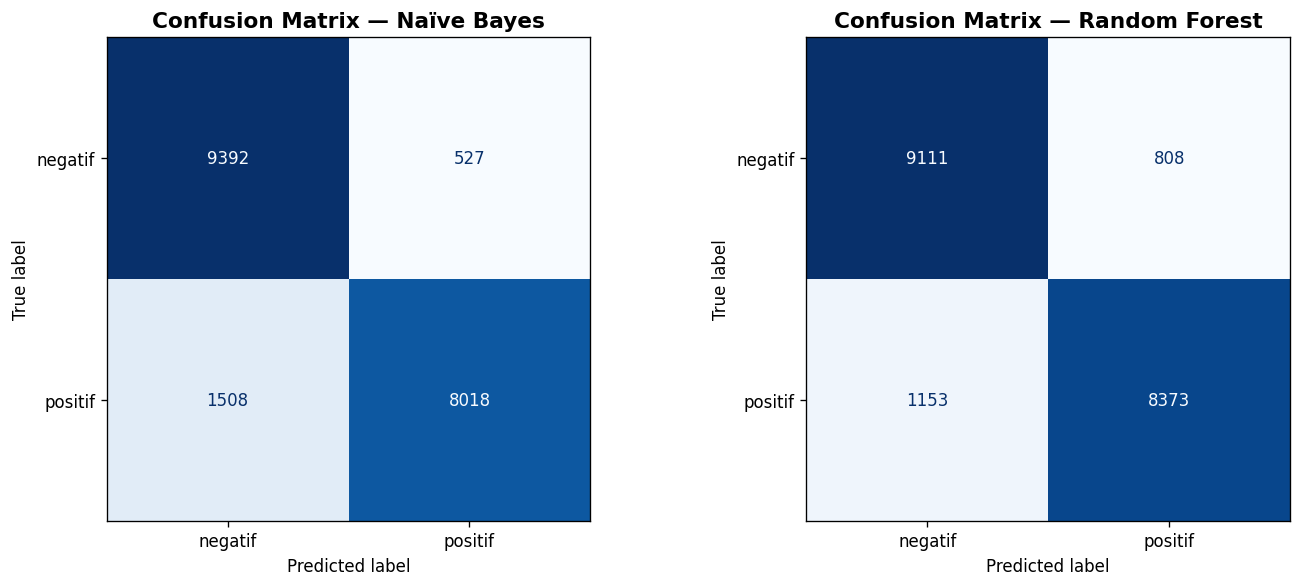

✅ Gambar disimpan: confusion_matrix_comparison.png


In [29]:
# ============================================================
# Confusion Matrix — Naïve Bayes & Random Forest
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['negatif', 'positif']

for ax, hasil, nama in zip(
    axes,
    [hasil_nb, hasil_rf],
    ['Naïve Bayes', 'Random Forest']
):
    cm = confusion_matrix(y_test, hasil['y_pred'], labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {nama}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('results/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: confusion_matrix_comparison.png')

## 6. Perbandingan Hasil & Kesimpulan

In [30]:
# ============================================================
# Tabel perbandingan metrik
# ============================================================

df_hasil = pd.DataFrame([
    {
        'Algoritma'  : 'Naïve Bayes',
        'Accuracy'   : f"{hasil_nb['accuracy']*100:.2f}%",
        'Precision'  : f"{hasil_nb['precision']*100:.2f}%",
        'Recall'     : f"{hasil_nb['recall']*100:.2f}%",
        'F1-Score'   : f"{hasil_nb['f1_score']*100:.2f}%",
        'Waktu Latih': f"{waktu_nb:.2f}s"
    },
    {
        'Algoritma'  : 'Random Forest',
        'Accuracy'   : f"{hasil_rf['accuracy']*100:.2f}%",
        'Precision'  : f"{hasil_rf['precision']*100:.2f}%",
        'Recall'     : f"{hasil_rf['recall']*100:.2f}%",
        'F1-Score'   : f"{hasil_rf['f1_score']*100:.2f}%",
        'Waktu Latih': f"{waktu_rf:.2f}s"
    }
])

print('\n📊 TABEL PERBANDINGAN HASIL')
print('='*70)
print(df_hasil.to_string(index=False))

# Simpan ke CSV
df_hasil.to_csv('results/hasil_evaluasi.csv', index=False)
print('\n✅ Hasil disimpan ke hasil_evaluasi.csv')


📊 TABEL PERBANDINGAN HASIL
    Algoritma Accuracy Precision Recall F1-Score Waktu Latih
  Naïve Bayes   89.53%    93.83% 84.17%   88.74%       0.13s
Random Forest   89.92%    91.20% 87.90%   89.52%     152.46s

✅ Hasil disimpan ke hasil_evaluasi.csv


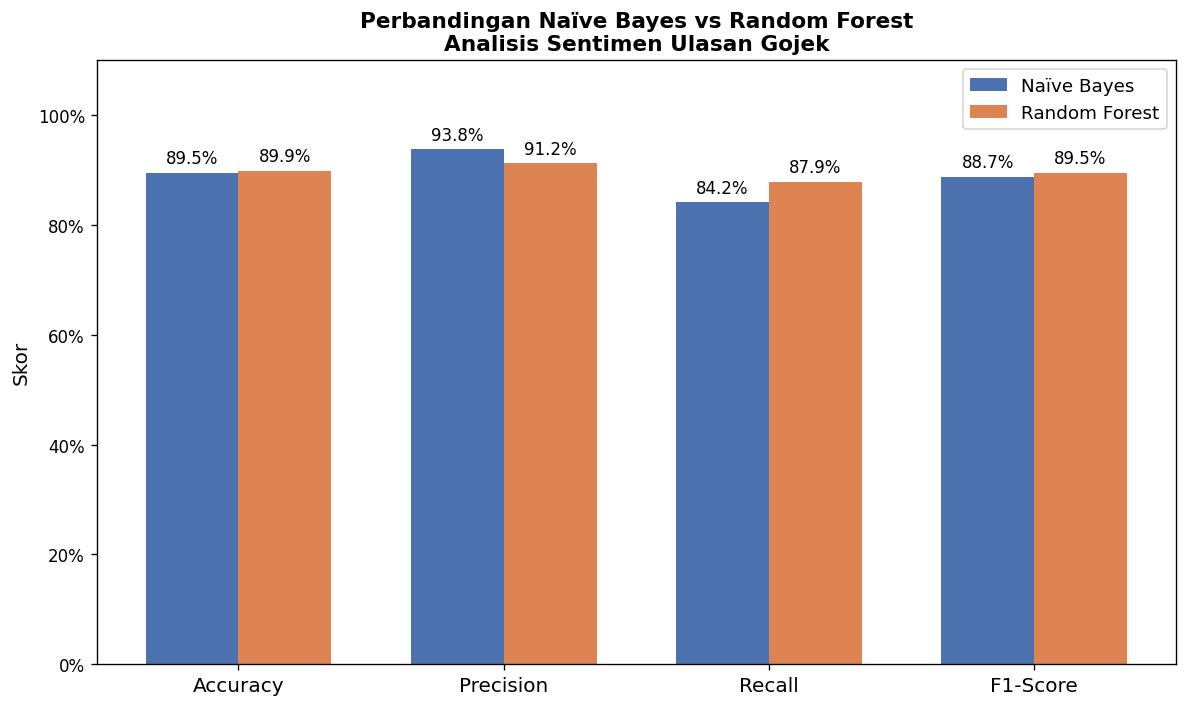

✅ Gambar disimpan: perbandingan_metrik.png


In [31]:
# ============================================================
# Bar chart perbandingan
# ============================================================

metrik_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
nb_scores = [
    hasil_nb['accuracy'], hasil_nb['precision'],
    hasil_nb['recall'],   hasil_nb['f1_score']
]
rf_scores = [
    hasil_rf['accuracy'], hasil_rf['precision'],
    hasil_rf['recall'],   hasil_rf['f1_score']
]

x = np.arange(len(metrik_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_nb = ax.bar(x - width/2, nb_scores, width, label='Naïve Bayes',    color='#4C72B0')
bars_rf = ax.bar(x + width/2, rf_scores, width, label='Random Forest',  color='#DD8452')

ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Perbandingan Naïve Bayes vs Random Forest\nAnalisis Sentimen Ulasan Gojek', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrik_names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))

# Label nilai di atas bar
for bar in bars_nb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/perbandingan_metrik.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: perbandingan_metrik.png')

In [32]:
# ============================================================
# Kesimpulan otomatis berdasarkan hasil
# ============================================================

selisih_acc = (hasil_rf['accuracy'] - hasil_nb['accuracy']) * 100
selisih_f1  = (hasil_rf['f1_score'] - hasil_nb['f1_score']) * 100

print('\n📋 KESIMPULAN PENELITIAN')
print('='*60)

if selisih_acc >= 5:
    print(f'H₁ DITERIMA: Random Forest unggul signifikan atas Naïve Bayes')
    print(f'  Selisih Accuracy : +{selisih_acc:.2f}% (≥ 5% threshold)')
    print(f'  Selisih F1-Score : +{selisih_f1:.2f}%')
    print(f'\n  → Random Forest lebih efektif untuk klasifikasi sentimen')
    print(f'    ulasan Gojek berbahasa Indonesia dengan TF-IDF.')
elif selisih_acc > 0:
    print(f'H₁ DITOLAK / H₀ DIPERTAHANKAN')
    print(f'  Selisih Accuracy : +{selisih_acc:.2f}% (< 5% threshold — tidak signifikan secara praktis)')
    print(f'  Selisih F1-Score : +{selisih_f1:.2f}%')
    print(f'\n  → Tidak ada perbedaan performa yang signifikan antara')
    print(f'    kedua algoritma pada dataset ini.')
else:
    print(f'H₁ DITOLAK: Naïve Bayes mengungguli Random Forest')
    print(f'  Selisih Accuracy : {selisih_acc:.2f}%')
    print(f'  Selisih F1-Score : {selisih_f1:.2f}%')

print('='*60)
print()
print('File output yang dihasilkan:')
print('  - hasil_evaluasi.csv')
print('  - confusion_matrix_comparison.png')
print('  - perbandingan_metrik.png')


📋 KESIMPULAN PENELITIAN
H₁ DITOLAK / H₀ DIPERTAHANKAN
  Selisih Accuracy : +0.38% (< 5% threshold — tidak signifikan secara praktis)
  Selisih F1-Score : +0.78%

  → Tidak ada perbedaan performa yang signifikan antara
    kedua algoritma pada dataset ini.

File output yang dihasilkan:
  - hasil_evaluasi.csv
  - confusion_matrix_comparison.png
  - perbandingan_metrik.png
